# Bonus: ReLU boundary geometry

This notebook builds the idea of a neural-network decision boundary slowly.

The path is:

1. one input number
2. one linear formula
3. one ReLU formula
4. several ReLU formulas
5. one weighted sum into a logit
6. one 2D point
7. many grid points
8. a drawn decision boundary

The goal is not to prove that a network can fit every dataset. The goal is to understand how ReLU hidden values combine into a flexible scoring function.


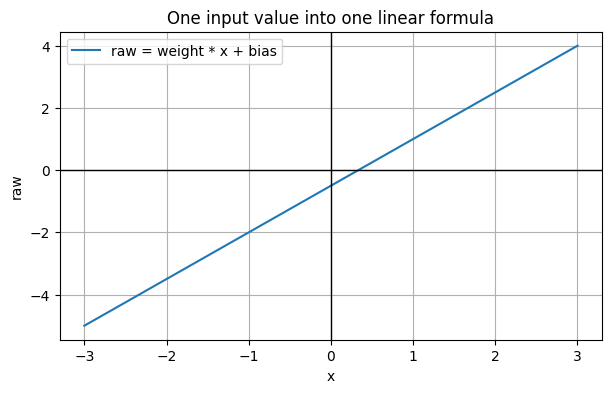

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

FloatArray = NDArray[np.float64]

artifact_dir = Path("artifacts/week-05-small-neural-networks")
artifact_dir.mkdir(parents=True, exist_ok=True)

x_values: FloatArray = np.linspace(-3.0, 3.0, 200)

weight: float = 1.5
bias: float = -0.5

raw_values: FloatArray = weight * x_values + bias

plt.figure(figsize=(7, 4))
plt.plot(x_values, raw_values, label="raw = weight * x + bias")
plt.axhline(0.0, color="black", linewidth=1)
plt.axvline(0.0, color="black", linewidth=1)
plt.xlabel("x")
plt.ylabel("raw")
plt.title("One input value into one linear formula")
plt.legend()
plt.grid(True)

plt.savefig(artifact_dir / "bonus_linear_formula_1d.png", dpi=150, bbox_inches="tight")
plt.show()

## One number into one linear formula

The first formula is:

```text
raw = weight * x + bias
```

The input is one number, `x`.

The `weight` changes how steeply the line rises or falls.

The `bias` shifts the whole line up or down. When `x = 0`, the raw value equals the bias.

At this point there is no ReLU and no neural network yet. This is only one linear formula.


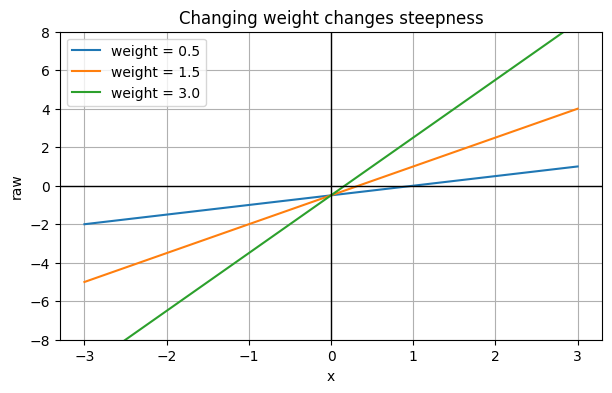

In [2]:
x_values: FloatArray = np.linspace(-3.0, 3.0, 200)

bias: float = -0.5
weights: list[float] = [0.5, 1.5, 3.0]

plt.figure(figsize=(7, 4))

for weight in weights:
    raw_values: FloatArray = weight * x_values + bias
    plt.plot(x_values, raw_values, label=f"weight = {weight}")

plt.axhline(0.0, color="black", linewidth=1)
plt.axvline(0.0, color="black", linewidth=1)
plt.ylim(-8.0, 8.0)
plt.xlabel("x")
plt.ylabel("raw")
plt.title("Changing weight changes steepness")
plt.legend()
plt.grid(True)
plt.show()

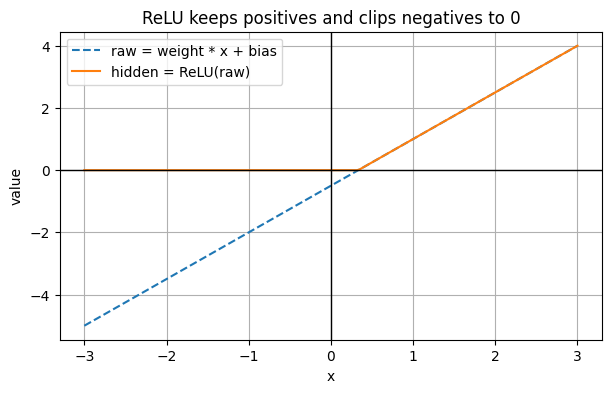

In [3]:
weight: float = 1.5
bias: float = -0.5

raw_values: FloatArray = weight * x_values + bias
hidden_values: FloatArray = np.maximum(0.0, raw_values)

plt.figure(figsize=(7, 4))
plt.plot(x_values, raw_values, label="raw = weight * x + bias", linestyle="--")
plt.plot(x_values, hidden_values, label="hidden = ReLU(raw)")
plt.axhline(0.0, color="black", linewidth=1)
plt.axvline(0.0, color="black", linewidth=1)
plt.xlabel("x")
plt.ylabel("value")
plt.title("ReLU keeps positives and clips negatives to 0")
plt.legend()
plt.grid(True)

plt.savefig(artifact_dir / "bonus_relu_formula_1d.png", dpi=150, bbox_inches="tight")
plt.show()

## One ReLU

ReLU means:

```text
hidden = ReLU(raw) = max(0, raw)
```

If `raw` is negative, ReLU outputs `0`.

If `raw` is positive, ReLU lets the value pass through unchanged.

So the ReLU shape is flat at `0` on one side, then rises like the original line on the other side.


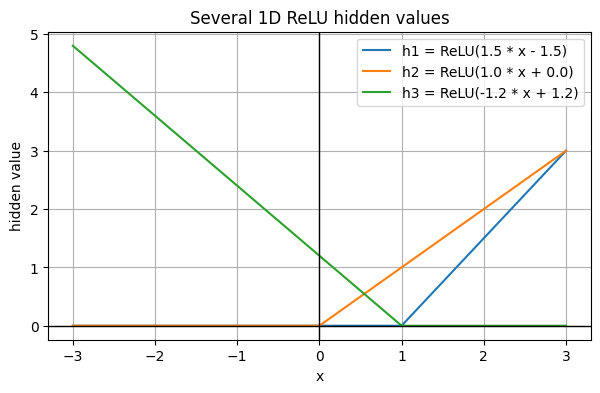

In [4]:
hidden_parameters: list[tuple[float, float, str]] = [
    (1.5, -1.5, "h1 = ReLU(1.5 * x - 1.5)"),
    (1.0, 0.0, "h2 = ReLU(1.0 * x + 0.0)"),
    (-1.2, 1.2, "h3 = ReLU(-1.2 * x + 1.2)"),
]

plt.figure(figsize=(7, 4))

for weight, bias, label in hidden_parameters:
    raw_values = weight * x_values + bias
    hidden_values = np.maximum(0.0, raw_values)
    plt.plot(x_values, hidden_values, label=label)

plt.axhline(0.0, color="black", linewidth=1)
plt.axvline(0.0, color="black", linewidth=1)
plt.xlabel("x")
plt.ylabel("hidden value")
plt.title("Several 1D ReLU hidden values")
plt.legend()
plt.grid(True)
plt.show()

## Several 1D ReLU hidden values

Each hidden value uses the same template:

```text
hidden_i = ReLU(weight_i * x + bias_i)
```

The difference is that each hidden value has its own weight and bias.

That means each ReLU can become active at a different place, and some can rise upward while others rise downward before being clipped by ReLU.


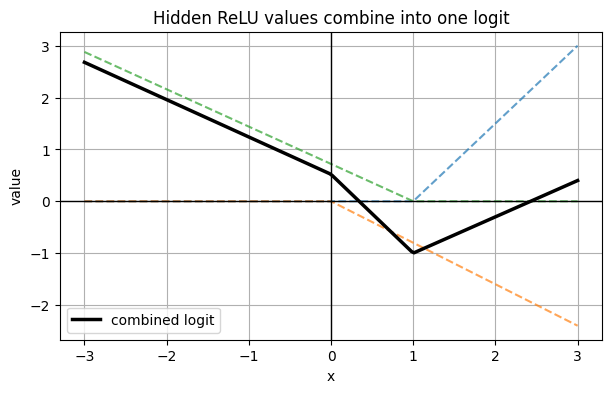

In [5]:
output_weights: list[float] = [1.0, -0.8, 0.6]
output_bias: float = -0.2

hidden_value_list: list[FloatArray] = []

for weight, bias, label in hidden_parameters:
    raw_values: FloatArray = weight * x_values + bias
    hidden_values: FloatArray = np.maximum(0.0, raw_values)
    hidden_value_list.append(hidden_values)

logit_values: FloatArray = np.full_like(x_values, fill_value=output_bias)

for hidden_values, output_weight in zip(hidden_value_list, output_weights):
    logit_values = logit_values + output_weight * hidden_values

plt.figure(figsize=(7, 4))

for hidden_values, output_weight in zip(hidden_value_list, output_weights):
    plt.plot(x_values, output_weight * hidden_values, linestyle="--", alpha=0.7)

plt.plot(x_values, logit_values, color="black", linewidth=2.5, label="combined logit")
plt.axhline(0.0, color="black", linewidth=1)
plt.axvline(0.0, color="black", linewidth=1)
plt.xlabel("x")
plt.ylabel("value")
plt.title("Hidden ReLU values combine into one logit")
plt.legend()
plt.grid(True)

plt.savefig(
    artifact_dir / "bonus_relu_sum_to_logit_1d.png", dpi=150, bbox_inches="tight"
)
plt.show()

## Hidden values combine into one logit

The output layer combines hidden values with a weighted sum:

```text
logit = output_bias
      + output_weight_1 * h1
      + output_weight_2 * h2
      + output_weight_3 * h3
```

A logit is the final raw score before sigmoid turns it into a probability.

The model does not keep several final answers. It combines the hidden values into one final logit.


In [6]:
x_position: float = 0.75
y_position: float = -0.25

weight_x: float = 1.2
weight_y: float = -0.7
bias: float = 0.1

raw: float = weight_x * x_position + weight_y * y_position + bias
hidden: float = max(0.0, raw)

print(f"x_position: {x_position}")
print(f"y_position: {y_position}")
print(f"raw: {raw:.3f}")
print(f"hidden = ReLU(raw): {hidden:.3f}")

x_position: 0.75
y_position: -0.25
raw: 1.175
hidden = ReLU(raw): 1.175


## From 1D to 2D

In 1D, one hidden unit used:

```text
hidden = ReLU(weight * x + bias)
```

In 2D, each point has two input values:

```text
x_position
y_position
```

So one hidden unit uses:

```text
hidden_i = ReLU(weight_ix * x_position + weight_iy * y_position + bias_i)
```

This is the same idea as before, but now each hidden unit needs one weight for `x_position` and one weight for `y_position`.


In [7]:
import math

x_position: float = 0.75
y_position: float = -0.25

hidden_parameters_2d: list[tuple[float, float, float, str]] = [
    (0.0, 1.0, 2.0, "h_y_reference"),
    (1.0, 0.0, 1.2, "h_left_bend"),
    (1.0, 0.0, -0.1, "h_middle_bend"),
    (1.0, 0.0, -1.2, "h_right_bend"),
]

output_weights_2d: list[float] = [1.0, -0.9, 1.4, -0.8]
output_bias_2d: float = -1.2

hidden_values_for_point: list[float] = []

for weight_x, weight_y, bias, name in hidden_parameters_2d:
    raw: float = weight_x * x_position + weight_y * y_position + bias
    hidden: float = max(0.0, raw)
    hidden_values_for_point.append(hidden)

    print(f"{name}: raw={raw:.3f}, hidden=ReLU(raw)={hidden:.3f}")

logit: float = output_bias_2d

for hidden_value, output_weight in zip(hidden_values_for_point, output_weights_2d):
    logit = logit + output_weight * hidden_value

probability: float = 1.0 / (1.0 + math.exp(-logit))
predicted_class: int = 1 if probability >= 0.5 else 0

print(f"logit: {logit:.3f}")
print(f"sigmoid probability: {probability:.3f}")
print(f"predicted class: {predicted_class}")

h_y_reference: raw=1.750, hidden=ReLU(raw)=1.750
h_left_bend: raw=1.950, hidden=ReLU(raw)=1.950
h_middle_bend: raw=0.650, hidden=ReLU(raw)=0.650
h_right_bend: raw=-0.450, hidden=ReLU(raw)=0.000
logit: -0.295
sigmoid probability: 0.427
predicted class: 0


## One point produces one output

For one point, the model path is:

```text
point -> hidden values -> logit -> sigmoid probability -> predicted class
```

The model outputs one logit for one point.

It does not output a decision boundary directly.


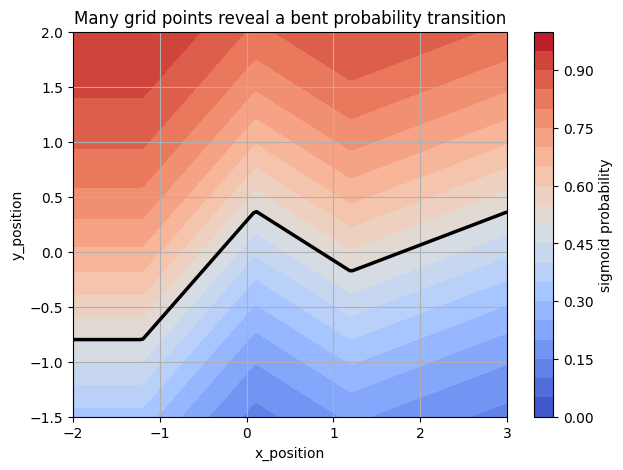

In [8]:
grid_x_values: FloatArray = np.linspace(-2.0, 3.0, 150)
grid_y_values: FloatArray = np.linspace(-1.5, 2.0, 150)

grid_x_matrix: FloatArray
grid_y_matrix: FloatArray
grid_x_matrix, grid_y_matrix = np.meshgrid(grid_x_values, grid_y_values)

hidden_grid_values: list[FloatArray] = []

for weight_x, weight_y, bias, name in hidden_parameters_2d:
    raw_grid_values: FloatArray = (
        weight_x * grid_x_matrix + weight_y * grid_y_matrix + bias
    )
    hidden_grid: FloatArray = np.maximum(0.0, raw_grid_values)
    hidden_grid_values.append(hidden_grid)

logit_grid: FloatArray = np.full_like(grid_x_matrix, fill_value=output_bias_2d)

for hidden_grid, output_weight in zip(hidden_grid_values, output_weights_2d):
    logit_grid = logit_grid + output_weight * hidden_grid

probability_grid: FloatArray = 1.0 / (1.0 + np.exp(-logit_grid))

plt.figure(figsize=(7, 5))

plt.contourf(
    grid_x_matrix,
    grid_y_matrix,
    probability_grid,
    levels=np.linspace(0.0, 1.0, 21),
    cmap="coolwarm",
    vmin=0.0,
    vmax=1.0,
)

plt.colorbar(label="sigmoid probability")

plt.contour(
    grid_x_matrix,
    grid_y_matrix,
    probability_grid,
    levels=[0.5],
    colors="black",
    linewidths=2.5,
)

plt.xlabel("x_position")
plt.ylabel("y_position")
plt.title("Many grid points reveal a bent probability transition")
plt.grid(True)
plt.show()

## Many grid points produce many probabilities

To make a picture, we ask the model about many fake grid points across the plot.

Each grid point produces its own logit and sigmoid probability.

The colored map is not one model output. It is many point outputs arranged back into a 2D picture.


In [9]:
hidden_parameters_2d: list[tuple[float, float, float, str]] = [
    (0.0, 1.0, 2.0, "h_y_reference"),
]

output_weights_2d: list[float] = [1.0]
output_bias_2d: float = -1.2
plt.savefig(artifact_dir / "bonus_boundary_1_unit.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [10]:
hidden_parameters_2d: list[tuple[float, float, float, str]] = [
    (0.0, 1.0, 2.0, "h_y_reference"),
    (1.0, 0.0, -0.1, "h_middle_bend"),
]

output_weights_2d: list[float] = [1.0, 0.8]
output_bias_2d: float = -1.2
plt.savefig(artifact_dir / "bonus_boundary_2_units.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [11]:
hidden_parameters_2d: list[tuple[float, float, float, str]] = [
    (0.0, 1.0, 2.0, "h_y_reference"),
    (1.0, 0.0, 1.6, "h_bend_1"),
    (1.0, 0.0, 0.9, "h_bend_2"),
    (1.0, 0.0, 0.2, "h_bend_3"),
    (1.0, 0.0, -0.5, "h_bend_4"),
    (1.0, 0.0, -1.2, "h_bend_5"),
    (-1.0, 0.0, 1.0, "h_reverse_bend_1"),
    (-1.0, 0.0, -0.8, "h_reverse_bend_2"),
]

output_weights_2d: list[float] = [
    1.0,
    -0.5,
    0.9,
    -1.1,
    1.0,
    -0.6,
    0.4,
    -0.3,
]

output_bias_2d: float = -1.2

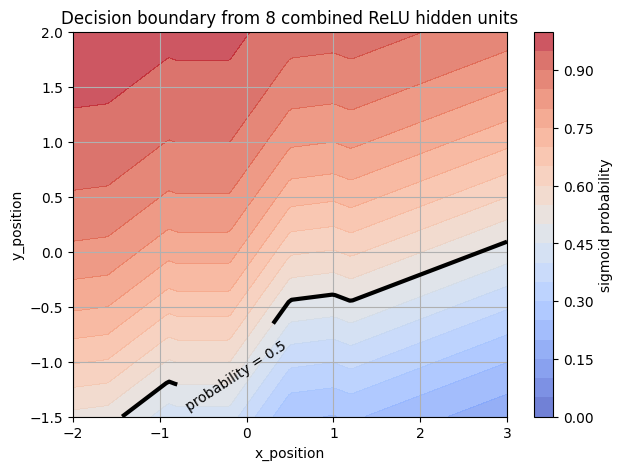

In [12]:
grid_x_values: FloatArray = np.linspace(-2.0, 3.0, 150)
grid_y_values: FloatArray = np.linspace(-1.5, 2.0, 150)

grid_x_matrix: FloatArray
grid_y_matrix: FloatArray
grid_x_matrix, grid_y_matrix = np.meshgrid(grid_x_values, grid_y_values)

hidden_grid_values: list[FloatArray] = []

for weight_x, weight_y, bias, name in hidden_parameters_2d:
    raw_grid_values: FloatArray = (
        weight_x * grid_x_matrix + weight_y * grid_y_matrix + bias
    )
    hidden_grid: FloatArray = np.maximum(0.0, raw_grid_values)
    hidden_grid_values.append(hidden_grid)

logit_grid: FloatArray = np.full_like(grid_x_matrix, fill_value=output_bias_2d)

for hidden_grid, output_weight in zip(hidden_grid_values, output_weights_2d):
    logit_grid = logit_grid + output_weight * hidden_grid

probability_grid: FloatArray = 1.0 / (1.0 + np.exp(-logit_grid))

plt.figure(figsize=(7, 5))

plt.contourf(
    grid_x_matrix,
    grid_y_matrix,
    probability_grid,
    levels=np.linspace(0.0, 1.0, 21),
    cmap="coolwarm",
    vmin=0.0,
    vmax=1.0,
    alpha=0.75,
)

plt.colorbar(label="sigmoid probability")

boundary = plt.contour(
    grid_x_matrix,
    grid_y_matrix,
    probability_grid,
    levels=[0.5],
    colors="black",
    linewidths=3.0,
)

plt.clabel(boundary, fmt="probability = %.1f")

plt.xlabel("x_position")
plt.ylabel("y_position")
plt.title("Decision boundary from 8 combined ReLU hidden units")
plt.grid(True)

plt.savefig(artifact_dir / "bonus_boundary_8_units.png", dpi=150, bbox_inches="tight")
plt.show()

## What the decision boundary really is

The decision boundary is the place where the sigmoid probability is `0.5`.

The black line is drawn after evaluating many grid points.

The model itself outputs:

```text
one point -> one logit -> one probability
```

It does not output a boundary object.

Important: one visible bend in the final boundary does not necessarily equal one hidden unit. The boundary comes from all hidden units and output-layer weights combined.


## Connection back to the Week 05 MLP

The hand-built examples used this shape:

```text
2 input values -> several ReLU hidden values -> 1 logit
```

The Week 05 MLP used:

```text
Linear(2 -> 16) -> ReLU -> Linear(16 -> 1)
```

That means each input point produced 16 hidden values before the final logit.

The difference is that this notebook used hand-chosen weights, while the Week 05 MLP learned its weights and biases from the moon dataset.

More hidden units can give the model more flexibility, but the final boundary still depends on the actual learned weights.

## What became clearer

- A ReLU hidden unit is a linear formula followed by `max(0, raw)`.
- Several hidden values are combined into one final logit.
- One point produces one logit, not a boundary.
- A decision boundary is drawn from many grid-point probabilities.

## What remains confusing

- How each individual hidden unit affects the final boundary shape.
- Why some extra hidden units create visible bends while others do not.
- How trained weights differ from hand-chosen weights in these examples.
